In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from copy import deepcopy

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
from google.colab import files

uploaded = files.upload()

Saving MSFT.xlsx to MSFT.xlsx


In [3]:
df = pd.read_excel("MSFT.xlsx")

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1986-03-13,0.088542,0.101563,0.088542,0.097222,0.059125,1031788800
1,1986-03-14,0.097222,0.102431,0.097222,0.100694,0.061237,308160000
2,1986-03-17,0.100694,0.103299,0.100694,0.102431,0.062293,133171200
3,1986-03-18,0.102431,0.103299,0.098958,0.099826,0.060709,67766400
4,1986-03-19,0.099826,0.100694,0.097222,0.098090,0.059653,47894400


In [4]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort chronologically
df = df.sort_values('Date')

# Remove duplicate dates
df = df.drop_duplicates(subset='Date')

# Keep only the columns needed for this project
df = df[['Date', 'Close']].copy()

# Set Date as index
df = df.set_index('Date')

print("Dataset shape:", df.shape)
print("Start date:", df.index.min())
print("End date:", df.index.max())

df.head()

Dataset shape: (10175, 1)
Start date: 1986-03-13 00:00:00
End date: 2026-08-03 00:00:00


,Close
Date,
1986-03-13,0.097222
1986-03-14,0.100694
1986-03-17,0.102431
1986-03-18,0.099826
1986-03-19,0.098090


In [5]:
print("========== DATA QUALITY ==========")

print("\nDataset shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate dates:")
print(df.index.duplicated().sum())

print("\nFirst date:")
print(df.index.min())

print("\nLast date:")
print(df.index.max())

print("\nStatistical summary:")
display(df.describe())

========== DATA QUALITY ==========

Dataset shape:
(10175, 1)

Data types:
Close    float64
dtype: object

Missing values:
Close    0
dtype: int64

Duplicate dates:
0

First date:
1986-03-13 00:00:00

Last date:
2026-08-03 00:00:00

Statistical summary:


,Close
count,10175.000000
mean,77.265124
std,121.097028
min,0.090278
25%,6.480469
50%,27.924999
75%,55.943750
max,542.070007


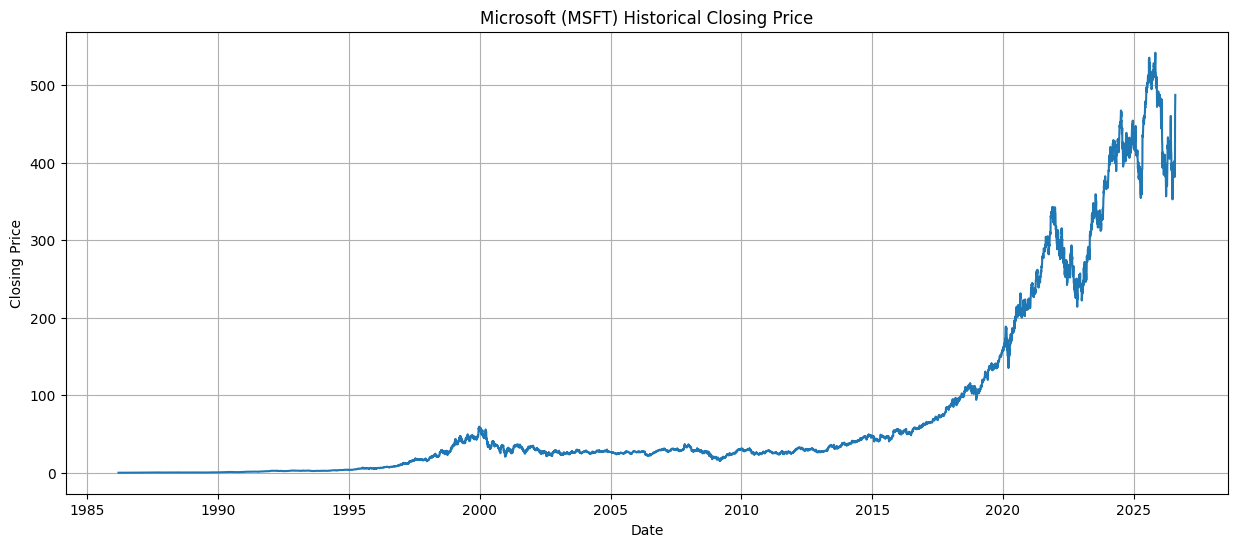

In [6]:
plt.figure(figsize=(15, 6))

plt.plot(df.index, df['Close'])

plt.title('Microsoft (MSFT) Historical Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)

plt.show()

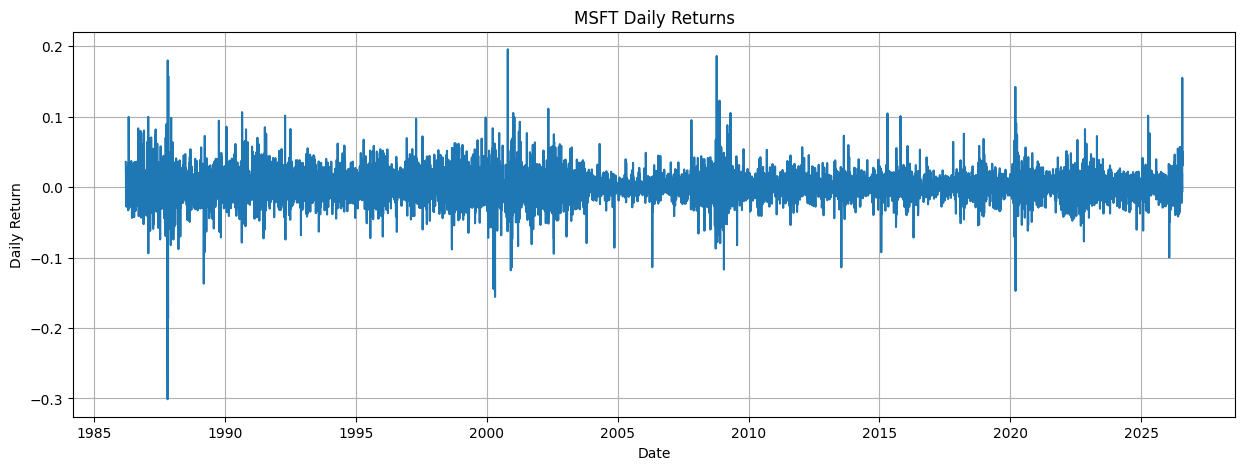

In [7]:
df['Daily Return'] = df['Close'].pct_change()

plt.figure(figsize=(15, 5))

plt.plot(df.index, df['Daily Return'])

plt.title('MSFT Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(True)

plt.show()

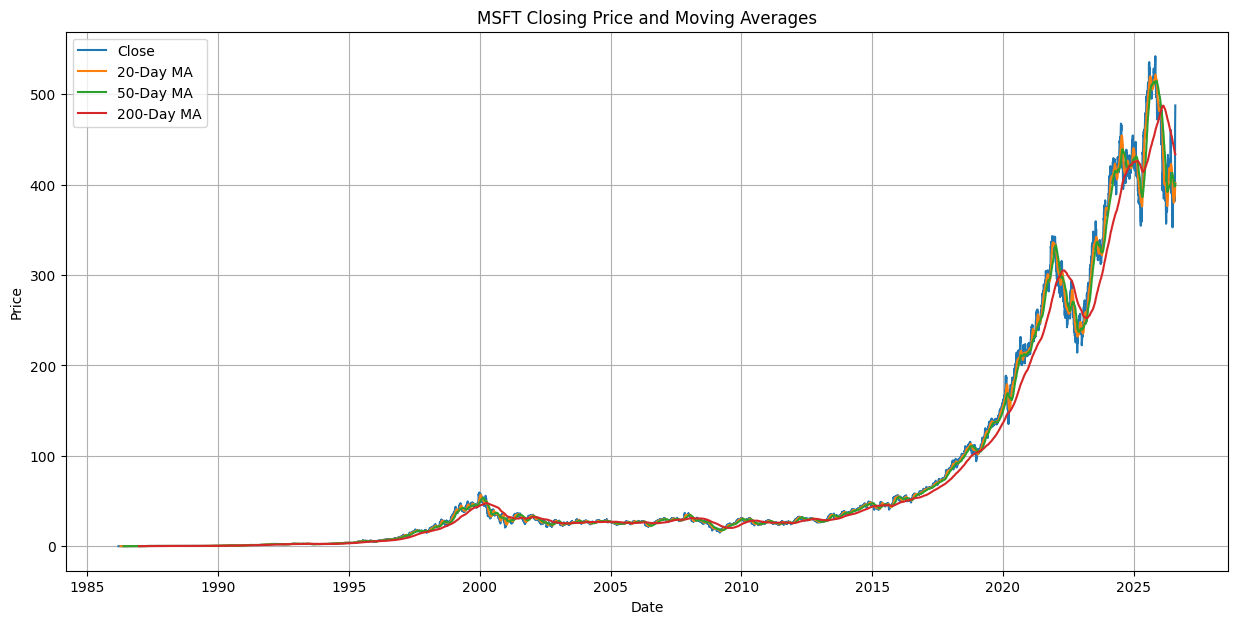

In [8]:
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(15, 7))

plt.plot(df.index, df['Close'], label='Close')
plt.plot(df.index, df['MA_20'], label='20-Day MA')
plt.plot(df.index, df['MA_50'], label='50-Day MA')
plt.plot(df.index, df['MA_200'], label='200-Day MA')

plt.title('MSFT Closing Price and Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()
plt.grid(True)

plt.show()

In [9]:
model_df = df[['Close']].copy()

model_df = model_df.dropna()

print("Modeling dataset:")
print(model_df.head())

print("\nShape:", model_df.shape)

Modeling dataset:
               Close
Date                
1986-03-13  0.097222
1986-03-14  0.100694
1986-03-17  0.102431
1986-03-18  0.099826
1986-03-19  0.098090

Shape: (10175, 1)


In [10]:
def df_to_windowed_df(dataframe, first_date, last_date, n=3):

    first_date = pd.to_datetime(first_date)
    last_date = pd.to_datetime(last_date)

    target_date = first_date

    dates = []
    X = []
    Y = []

    while target_date <= last_date:

        # Find the position of the target date
        try:
            target_index = dataframe.index.get_loc(target_date)
        except KeyError:
            target_date += pd.Timedelta(days=1)
            continue

        # Need n previous trading days
        if target_index < n:
            target_date += pd.Timedelta(days=1)
            continue

        # Previous n closing prices
        window = dataframe.iloc[
            target_index - n:target_index
        ]['Close'].values

        # Target closing price
        target = dataframe.iloc[target_index]['Close']

        dates.append(target_date)
        X.append(window)
        Y.append(target)

        target_date += pd.Timedelta(days=1)

    return (
        np.array(dates),
        np.array(X),
        np.array(Y)
    )

In [11]:
dates, X, y = df_to_windowed_df(
    model_df,
    '2021-03-25',
    '2026-07-23',
    n=3
)

print("Dates shape:", dates.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

Dates shape: (1338,)
X shape: (1338, 3)
y shape: (1338,)


In [12]:
X = X.reshape(
    (X.shape[0], X.shape[1], 1)
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1338, 3, 1)
y shape: (1338,)


In [13]:
q_80 = int(len(dates) * 0.80)
q_90 = int(len(dates) * 0.90)

dates_train = dates[:q_80]
X_train = X[:q_80]
y_train = y[:q_80]

dates_val = dates[q_80:q_90]
X_val = X[q_80:q_90]
y_val = y[q_80:q_90]

dates_test = dates[q_90:]
X_test = X[q_90:]
y_test = y[q_90:]

print("TRAIN")
print("Dates:", dates_train.shape)
print("X:", X_train.shape)
print("y:", y_train.shape)

print("\nVALIDATION")
print("Dates:", dates_val.shape)
print("X:", X_val.shape)
print("y:", y_val.shape)

print("\nTEST")
print("Dates:", dates_test.shape)
print("X:", X_test.shape)
print("y:", y_test.shape)

TRAIN
Dates: (1070,)
X: (1070, 3, 1)
y: (1070,)

VALIDATION
Dates: (134,)
X: (134, 3, 1)
y: (134,)

TEST
Dates: (134,)
X: (134, 3, 1)
y: (134,)


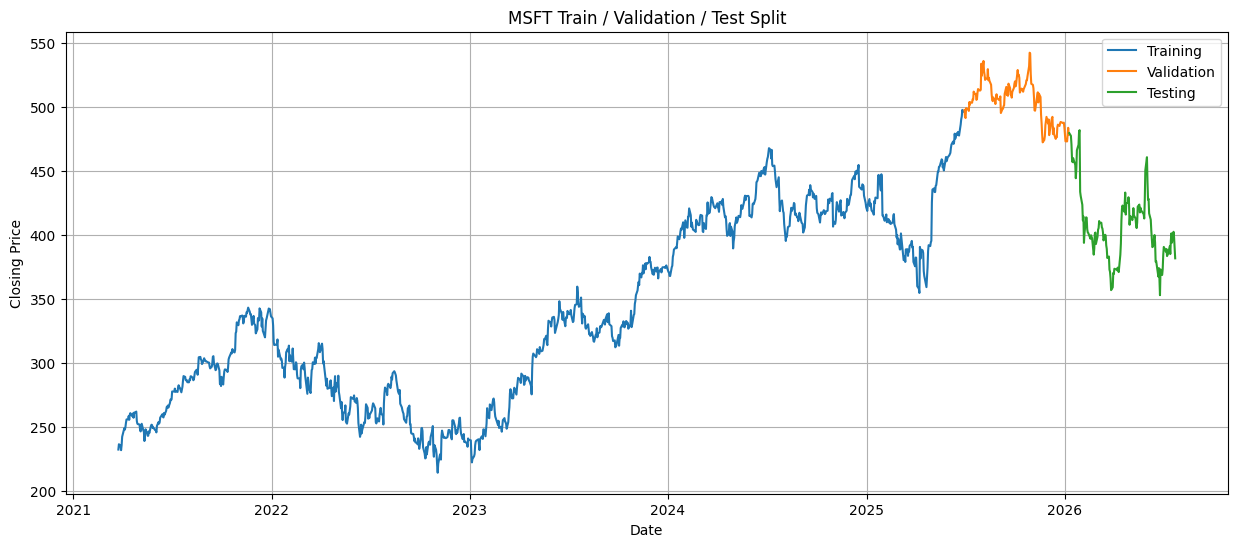

In [14]:
plt.figure(figsize=(15, 6))

plt.plot(dates_train, y_train, label='Training')
plt.plot(dates_val, y_val, label='Validation')
plt.plot(dates_test, y_test, label='Testing')

plt.title('MSFT Train / Validation / Test Split')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.legend()
plt.grid(True)

plt.show()

In [15]:
baseline_predictions = X_test[:, -1, 0]

print("Baseline predictions:", baseline_predictions.shape)
print("Actual test values:", y_test.shape)

Baseline predictions: (134,)
Actual test values: (134,)


In [16]:
model = Sequential([
    layers.Input(shape=(3, 1)),

    layers.LSTM(64),

    layers.Dense(32, activation='relu'),

    layers.Dense(32, activation='relu'),

    layers.Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,065 (78.38 KB)

 Trainable params: 20,065 (78.38 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    loss='mse',
    optimizer=Adam(learning_rate=0.001),
    metrics=['mean_absolute_error']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=100,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 116782.8828 - mean_absolute_error: 334.3166 - val_loss: 251228.3906 - val_mean_absolute_error: 500.9713
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 112822.7188 - mean_absolute_error: 328.3258 - val_loss: 240301.6875 - val_mean_absolute_error: 489.9442
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 99768.5547 - mean_absolute_error: 307.6444 - val_loss: 207490.0312 - val_mean_absolute_error: 455.2292
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 69730.7422 - mean_absolute_error: 253.7697 - val_loss: 144944.4531 - val_mean_absolute_error: 380.3792
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 32851.8711 - mean_absolute_error: 164.5620 - val_loss: 77662.0938 - val_mean_absolute_error: 278.2192
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9423.3145 - mean_absolute_error: 76.5612 - val_loss: 36038.5938 - val_mean_absolute_error: 189.1625
Epoch 7/100
34/34 ━━━━━━━━━━━

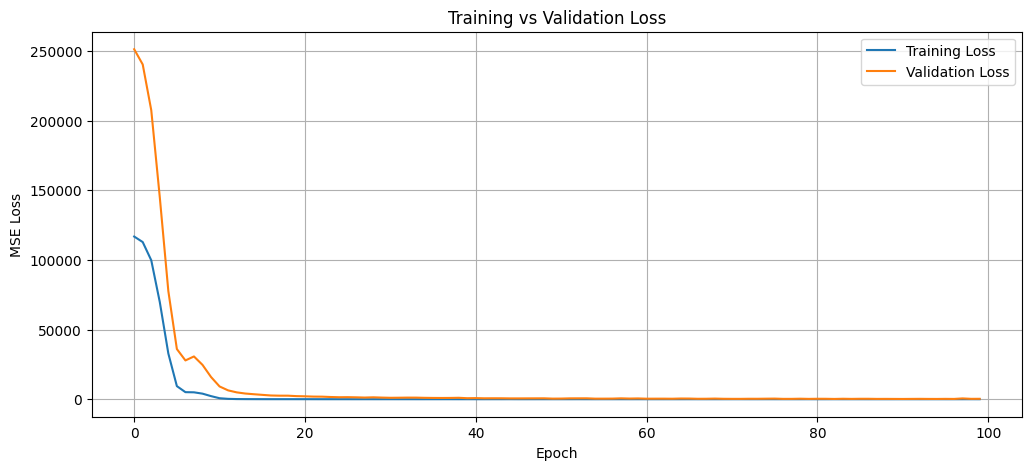

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.legend()
plt.grid(True)

plt.show()

In [19]:
train_predictions = model.predict(
    X_train,
    verbose=0
).flatten()

print("Training predictions:", train_predictions.shape)

Training predictions: (1070,)


In [20]:
val_predictions = model.predict(
    X_val,
    verbose=0
).flatten()

print("Validation predictions:", val_predictions.shape)

Validation predictions: (134,)


In [21]:
test_predictions = model.predict(
    X_test,
    verbose=0
).flatten()

print("Test predictions:", test_predictions.shape)

Test predictions: (134,)


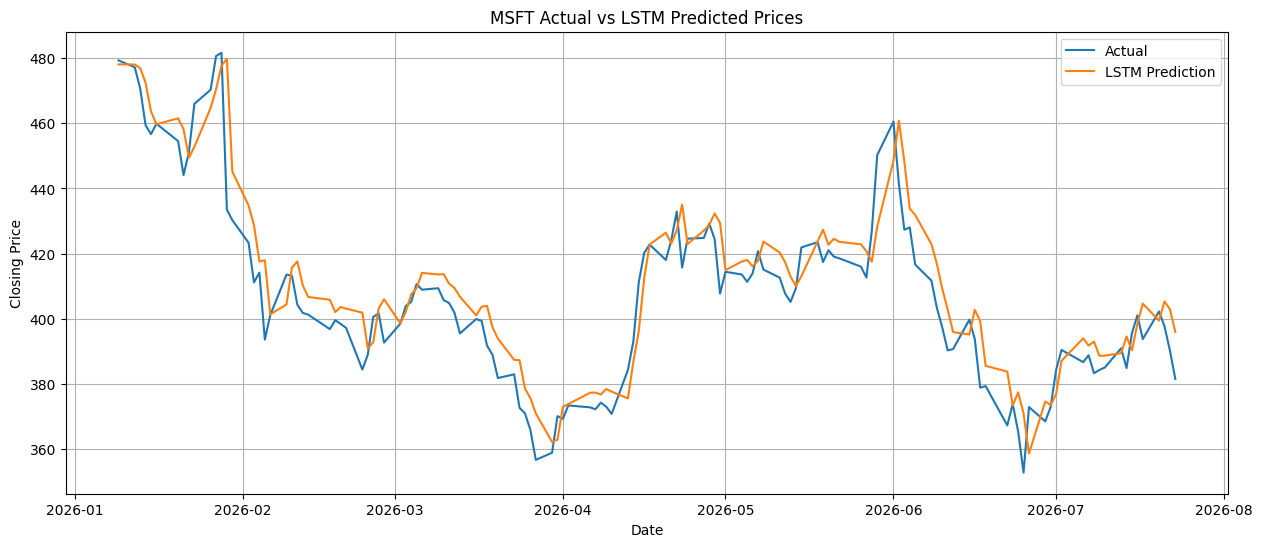

In [22]:
plt.figure(figsize=(15, 6))

plt.plot(
    dates_test,
    y_test,
    label='Actual'
)

plt.plot(
    dates_test,
    test_predictions,
    label='LSTM Prediction'
)

plt.title('MSFT Actual vs LSTM Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.legend()
plt.grid(True)

plt.show()

In [23]:
# ==============================
# LSTM METRICS
# ==============================

lstm_mae = mean_absolute_error(
    y_test,
    test_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

lstm_r2 = r2_score(
    y_test,
    test_predictions
)

lstm_mape = np.mean(
    np.abs(
        (y_test - test_predictions) / y_test
    )
) * 100


# ==============================
# BASELINE METRICS
# ==============================

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

baseline_mape = np.mean(
    np.abs(
        (y_test - baseline_predictions) / y_test
    )
) * 100


print("========== LSTM ==========")

print(f"MAE  : {lstm_mae:.4f}")
print(f"RMSE : {lstm_rmse:.4f}")
print(f"MAPE : {lstm_mape:.2f}%")
print(f"R²   : {lstm_r2:.4f}")


print("\n========== NAIVE BASELINE ==========")

print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"MAPE : {baseline_mape:.2f}%")
print(f"R²   : {baseline_r2:.4f}")

========== LSTM ==========
MAE  : 7.8908
RMSE : 10.1675
MAPE : 1.95%
R²   : 0.8641

========== NAIVE BASELINE ==========
MAE  : 6.5122
RMSE : 8.9126
MAPE : 1.60%
R²   : 0.8956


In [24]:
comparison = pd.DataFrame({

    'Model': [
        'Naive Baseline',
        'LSTM'
    ],

    'MAE': [
        baseline_mae,
        lstm_mae
    ],

    'RMSE': [
        baseline_rmse,
        lstm_rmse
    ],

    'MAPE (%)': [
        baseline_mape,
        lstm_mape
    ],

    'R²': [
        baseline_r2,
        lstm_r2
    ]
})

display(comparison)

,Model,MAE,RMSE,MAPE (%),R²
0,Naive Baseline,6.512165,8.912650,1.599798,0.895561
1,LSTM,7.890779,10.167522,1.950939,0.864081


In [25]:
actual_direction = np.sign(
    y_test[1:] - y_test[:-1]
)

predicted_direction = np.sign(
    test_predictions[1:] - test_predictions[:-1]
)

directional_accuracy = (
    np.mean(
        actual_direction == predicted_direction
    ) * 100
)

print(
    f"Directional Accuracy: "
    f"{directional_accuracy:.2f}%"
)

Directional Accuracy: 52.63%


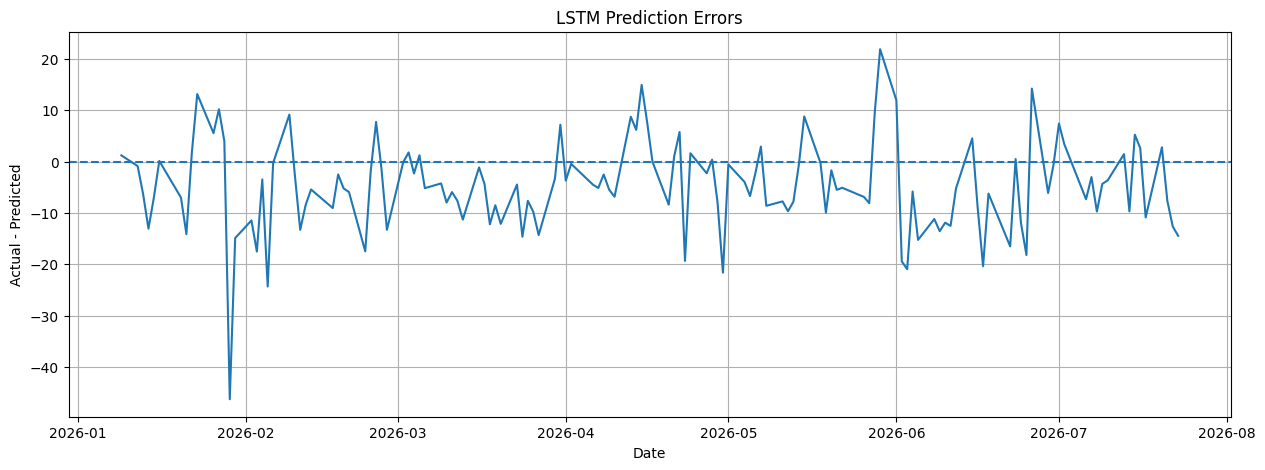

In [26]:
errors = y_test - test_predictions

plt.figure(figsize=(15, 5))

plt.plot(
    dates_test,
    errors
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title('LSTM Prediction Errors')
plt.xlabel('Date')
plt.ylabel('Actual - Predicted')

plt.grid(True)

plt.show()

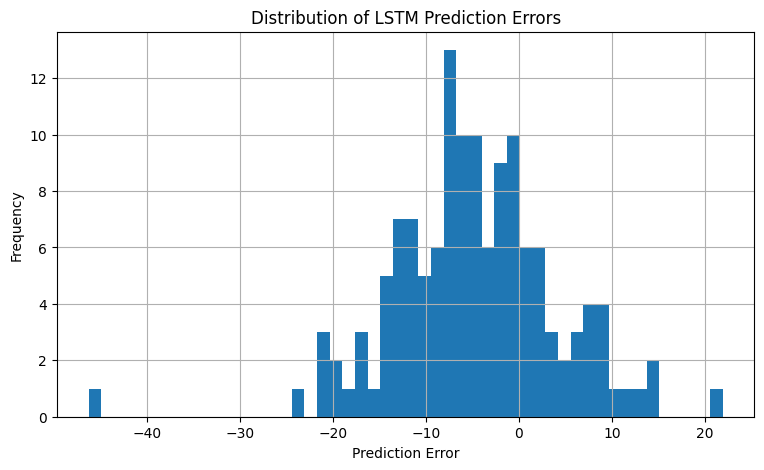

In [27]:
plt.figure(figsize=(9, 5))

plt.hist(
    errors,
    bins=50
)

plt.title('Distribution of LSTM Prediction Errors')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')

plt.grid(True)

plt.show()

In [28]:
recursive_predictions = []

recursive_dates = np.concatenate([
    dates_val,
    dates_test
])

# IMPORTANT:
# Create the window ONCE, outside the loop.
last_window = deepcopy(X_train[-1])

for target_date in recursive_dates:

    next_prediction = model.predict(
        np.array([last_window]),
        verbose=0
    ).flatten()[0]

    recursive_predictions.append(
        next_prediction
    )

    # Shift the window
    last_window[:-1] = last_window[1:]

    # Add the new prediction
    last_window[-1] = next_prediction

recursive_predictions = np.array(
    recursive_predictions
)

print(
    "Recursive predictions:",
    recursive_predictions.shape
)

print(
    "Recursive dates:",
    recursive_dates.shape
)

Recursive predictions: (268,)
Recursive dates: (268,)


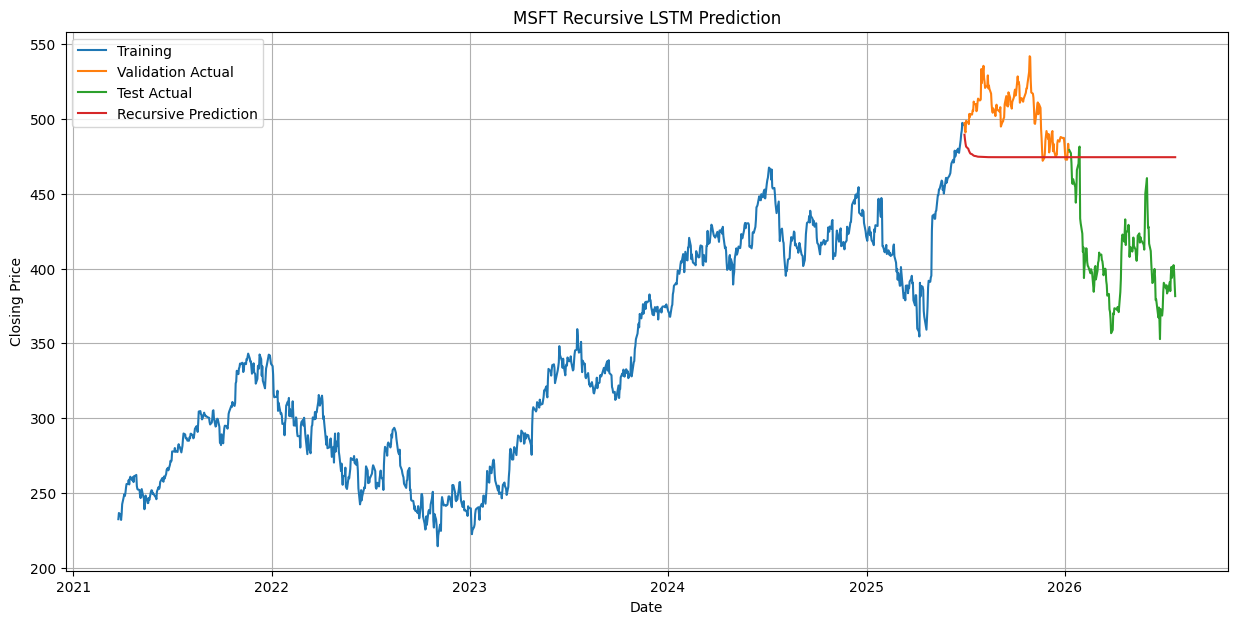

In [29]:
plt.figure(figsize=(15, 7))

plt.plot(
    dates_train,
    y_train,
    label='Training'
)

plt.plot(
    dates_val,
    y_val,
    label='Validation Actual'
)

plt.plot(
    dates_test,
    y_test,
    label='Test Actual'
)

plt.plot(
    recursive_dates,
    recursive_predictions,
    label='Recursive Prediction'
)

plt.title(
    'MSFT Recursive LSTM Prediction'
)

plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.legend()
plt.grid(True)

plt.show()

In [30]:
recursive_test_predictions = recursive_predictions[
    len(dates_val):
]

recursive_test_mae = mean_absolute_error(
    y_test,
    recursive_test_predictions
)

recursive_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        recursive_test_predictions
    )
)

recursive_test_r2 = r2_score(
    y_test,
    recursive_test_predictions
)

recursive_test_mape = np.mean(
    np.abs(
        (y_test - recursive_test_predictions)
        / y_test
    )
) * 100


print("========== RECURSIVE TEST ==========")

print(
    f"MAE  : {recursive_test_mae:.4f}"
)

print(
    f"RMSE : {recursive_test_rmse:.4f}"
)

print(
    f"MAPE : {recursive_test_mape:.2f}%"
)

print(
    f"R²   : {recursive_test_r2:.4f}"
)

========== RECURSIVE TEST ==========
MAE  : 68.3661
RMSE : 73.4343
MAPE : 17.33%
R²   : -6.0900


In [31]:
future_predictions = []

# Start from the latest available test window
last_window = deepcopy(X_test[-1])

for _ in range(30):

    prediction = model.predict(
        np.array([last_window]),
        verbose=0
    ).flatten()[0]

    future_predictions.append(
        prediction
    )

    # Shift window
    last_window[:-1] = last_window[1:]

    # Add prediction
    last_window[-1] = prediction


future_predictions = np.array(
    future_predictions
)

print("30-day forecast:")
print(future_predictions)

30-day forecast:
[396.015   399.63483 403.5364  407.34732 411.1162  414.82547 418.46878
 422.0388  425.52902 428.9335  432.24643 435.47046 438.60144 441.63193
 444.55426 447.35986 450.03952 452.5836  454.98236 457.22684 459.30948
 461.22473 462.96982 464.5449  465.95322 467.20102 468.29694 469.25177
 470.07736 470.78656]


In [32]:
future_dates = pd.bdate_range(
    start=df.index[-1],
    periods=31
)[1:]

print(future_dates)

DatetimeIndex(['2026-08-04', '2026-08-05', '2026-08-06', '2026-08-07',
               '2026-08-10', '2026-08-11', '2026-08-12', '2026-08-13',
               '2026-08-14', '2026-08-17', '2026-08-18', '2026-08-19',
               '2026-08-20', '2026-08-21', '2026-08-24', '2026-08-25',
               '2026-08-26', '2026-08-27', '2026-08-28', '2026-08-31',
               '2026-09-01', '2026-09-02', '2026-09-03', '2026-09-04',
               '2026-09-07', '2026-09-08', '2026-09-09', '2026-09-10',
               '2026-09-11', '2026-09-14'],
              dtype='datetime64[ns]', freq='B')


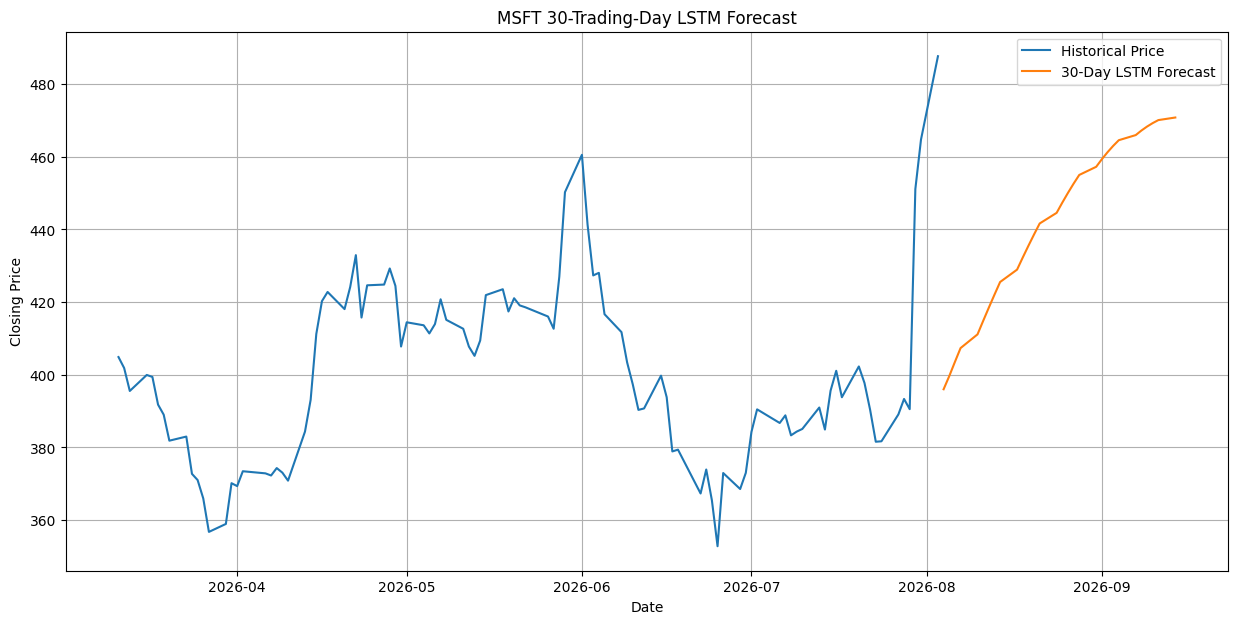

In [33]:
plt.figure(figsize=(15, 7))

# Last 100 actual observations
recent_dates = df.index[-100:]
recent_prices = df['Close'].iloc[-100:]

plt.plot(
    recent_dates,
    recent_prices,
    label='Historical Price'
)

plt.plot(
    future_dates,
    future_predictions,
    label='30-Day LSTM Forecast'
)

plt.title(
    'MSFT 30-Trading-Day LSTM Forecast'
)

plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.legend()
plt.grid(True)

plt.show()

In [34]:
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Close': future_predictions
})

display(forecast_df)

,Date,Predicted Close
0,2026-08-04,396.015015
1,2026-08-05,399.634827
2,2026-08-06,403.536407
3,2026-08-07,407.347321
4,2026-08-10,411.116211
5,2026-08-11,414.825470
6,2026-08-12,418.468781
7,2026-08-13,422.038788
8,2026-08-14,425.529022
9,2026-08-17,428.933502


In [35]:
print("=" * 55)
print("       MSFT LSTM STOCK PREDICTION RESULTS")
print("=" * 55)

print("\nMODEL PERFORMANCE")
print("-" * 55)

print(
    f"LSTM MAE              : {lstm_mae:.4f}"
)

print(
    f"LSTM RMSE             : {lstm_rmse:.4f}"
)

print(
    f"LSTM MAPE             : {lstm_mape:.2f}%"
)

print(
    f"LSTM R²               : {lstm_r2:.4f}"
)

print(
    f"Directional Accuracy  : "
    f"{directional_accuracy:.2f}%"
)


print("\nNAIVE BASELINE")
print("-" * 55)

print(
    f"Baseline MAE          : {baseline_mae:.4f}"
)

print(
    f"Baseline RMSE         : {baseline_rmse:.4f}"
)


print("\nRECURSIVE FORECAST")
print("-" * 55)

print(
    f"Recursive MAE         : "
    f"{recursive_test_mae:.4f}"
)

print(
    f"Recursive RMSE        : "
    f"{recursive_test_rmse:.4f}"
)


print("\nFUTURE FORECAST")
print("-" * 55)

print(
    f"Last actual price     : "
    f"{df['Close'].iloc[-1]:.2f}"
)

print(
    f"First forecast        : "
    f"{future_predictions[0]:.2f}"
)

print(
    f"30th forecast         : "
    f"{future_predictions[-1]:.2f}"
)

print("\n" + "=" * 55)

       MSFT LSTM STOCK PREDICTION RESULTS

MODEL PERFORMANCE
-------------------------------------------------------
LSTM MAE              : 7.8908
LSTM RMSE             : 10.1675
LSTM MAPE             : 1.95%
LSTM R²               : 0.8641
Directional Accuracy  : 52.63%

NAIVE BASELINE
-------------------------------------------------------
Baseline MAE          : 6.5122
Baseline RMSE         : 8.9126

RECURSIVE FORECAST
-------------------------------------------------------
Recursive MAE         : 68.3661
Recursive RMSE        : 73.4343

FUTURE FORECAST
-------------------------------------------------------
Last actual price     : 487.65
First forecast        : 396.02
30th forecast         : 470.79

